Estimated beta (intercept, slope): [51143.56743319 18955.87321318]

Interpolated target means:
T1: £54,935
T2: £66,308

Areal weighting estimates:
T1: £60,825
T2: £63,006


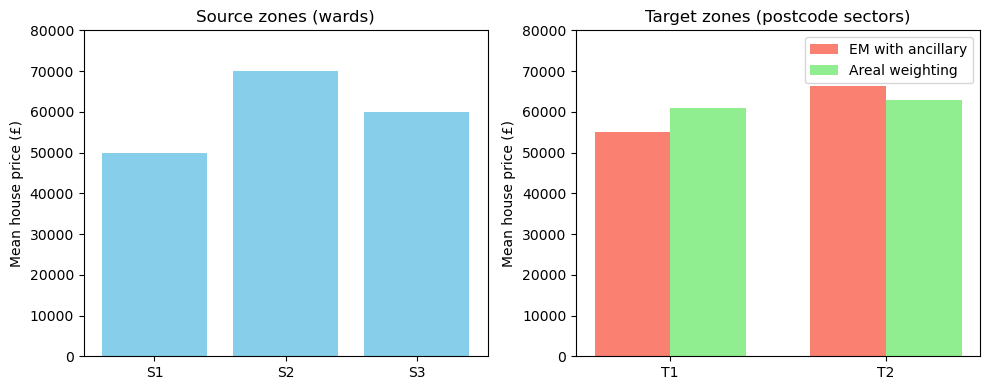

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import lstsq

# -------------------------------
# Toy data
# -------------------------------

# Source zones
source_ids = ['S1', 'S2', 'S3']
n_s = np.array([100, 200, 150])          # number of observations per source zone
y_s = np.array([50000, 70000, 60000])    # observed mean house prices

# Target zones
target_ids = ['T1', 'T2']
X_t = np.array([[1, 0.2],                # ancillary: intercept + % large-user
                [1, 0.8]])               # T1 has 20%, T2 has 80%

# Intersection areas A_st (rows=source, cols=target)
A_st = np.array([[10, 5],   # S1 intersects T1 (10 ha), T2 (5 ha)
                 [8, 12],   # S2
                 [2, 18]])  # S3

# Areas of source zones
A_s = A_st.sum(axis=1)     # [15, 20, 20]

# Estimate n_st via areal weighting
n_st = (A_st / A_s[:, None]) * n_s[:, None]

# Total n_t (for target zones)
n_t = n_st.sum(axis=0)

# -------------------------------
# Direct EM solution (non-iterative)
# -------------------------------

# Compute P matrix: p_st = n_st / n_s
P = n_st / n_s[:, None]

# Design matrix for source zones: X_s = P * X_t
X_s = P @ X_t

# Weighted least squares to estimate beta
W = np.diag(n_s)          # weights
XTWX = X_s.T @ W @ X_s
XTWy = X_s.T @ W @ y_s
beta = np.linalg.solve(XTWX, XTWy)

print("Estimated beta (intercept, slope):", beta)

# Predicted mu_t for target zones
mu_t = X_t @ beta

# -------------------------------
# E-step to get final y_t (pycnophylactic adjustment)
# -------------------------------

# Compute mu_s from predicted mu_t
mu_s = P @ mu_t

# Adjust mu_st to match observed y_s
mu_st = mu_t[None, :] + (y_s[:, None] - mu_s[:, None])

# Final interpolated target means
y_t = (n_st * mu_st).sum(axis=0) / n_t

print("\nInterpolated target means:")
for tid, val in zip(target_ids, y_t):
    print(f"{tid}: £{val:,.0f}")

# -------------------------------
# Comparison with areal weighting
# -------------------------------

# Areal weighting: assume y_st = y_s
y_t_aw = (n_st * y_s[:, None]).sum(axis=0) / n_t

print("\nAreal weighting estimates:")
for tid, val in zip(target_ids, y_t_aw):
    print(f"{tid}: £{val:,.0f}")

# -------------------------------
# Graphical illustration
# -------------------------------

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: Observed source means
axes[0].bar(source_ids, y_s, color='skyblue', label='Observed')
axes[0].set_ylabel('Mean house price (£)')
axes[0].set_title('Source zones (wards)')
axes[0].set_ylim(0, 80000)

# Right: Interpolated target means (EM vs Areal)
x = np.arange(len(target_ids))
width = 0.35
axes[1].bar(x - width/2, y_t, width, label='EM with ancillary', color='salmon')
axes[1].bar(x + width/2, y_t_aw, width, label='Areal weighting', color='lightgreen')
axes[1].set_xticks(x)
axes[1].set_xticklabels(target_ids)
axes[1].set_ylabel('Mean house price (£)')
axes[1].set_title('Target zones (postcode sectors)')
axes[1].legend()
axes[1].set_ylim(0, 80000)

plt.tight_layout()
plt.show()

C:\Users\renan\AppData\Local\Temp\ipykernel_39848\880867606.py:57: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = cells_in_zone.geometry.unary_union
C:\Users\renan\AppData\Local\Temp\ipykernel_39848\880867606.py:57: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = cells_in_zone.geometry.unary_union
C:\Users\renan\AppData\Local\Temp\ipykernel_39848\880867606.py:57: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = cells_in_zone.geometry.unary_union
C:\Users\renan\AppData\Local\Temp\ipykernel_39848\880867606.py:57: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = cells_in_zone.geometry.unary_union
C:\Users\renan\AppData\Local\Temp\ipykernel_39848\880867606.py:57: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' 

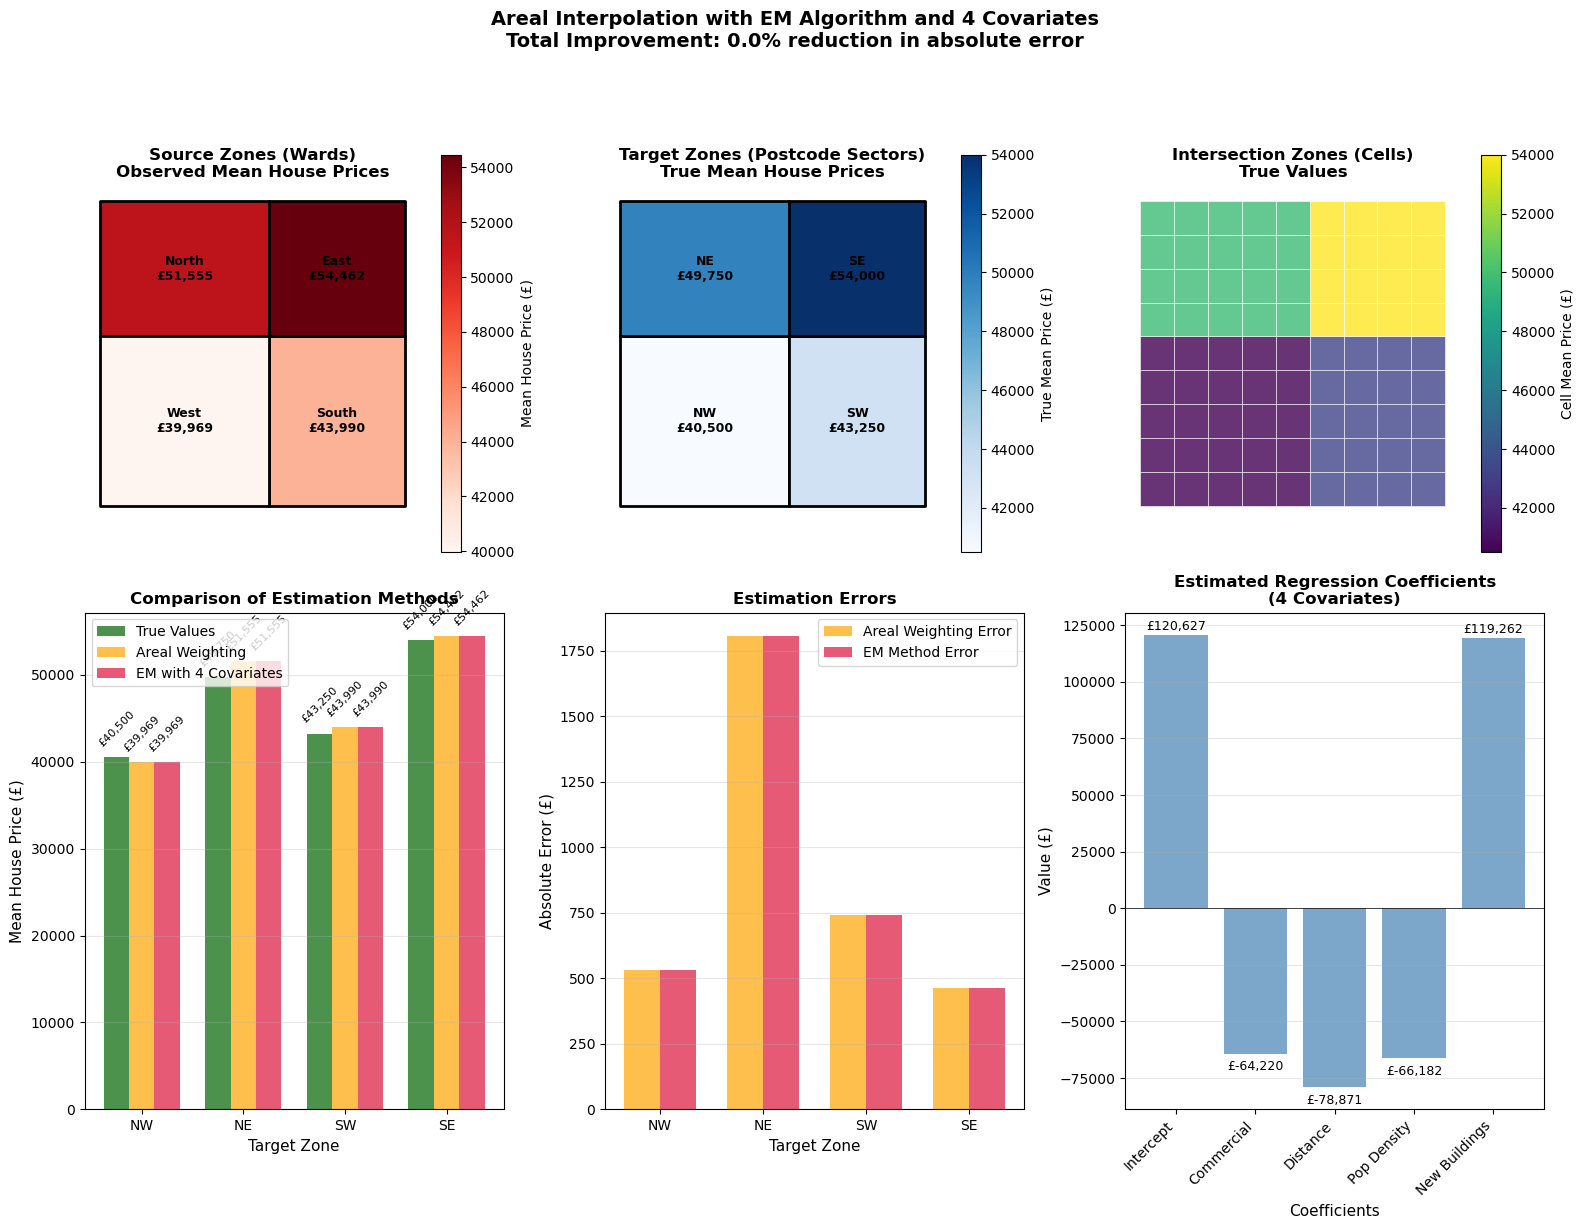


DETAILED RESULTS

📊 ESTIMATED REGRESSION COEFFICIENTS (4 Covariates):
--------------------------------------------------
  Intercept      : £   120,627
  Commercial     : £   -64,220
  Distance       : £   -78,871
  Pop Density    : £   -66,182
  New Buildings  : £   119,262

📈 TARGET ZONE ESTIMATES:
----------------------------------------------------------------------
Zone     True Mean       Areal Weighting      EM Estimate     Improvement    
----------------------------------------------------------------------
NW       £      40,500  £           39,969  £      39,969            0.0%
NE       £      49,750  £           51,555  £      51,555            0.0%
SW       £      43,250  £           43,990  £      43,990            0.0%
SE       £      54,000  £           54,462  £      54,462            0.0%

📉 ERROR STATISTICS:
--------------------------------------------------
  Total Absolute Error (Areal): £3,538
  Total Absolute Error (EM):    £3,538
  Improvement:                 

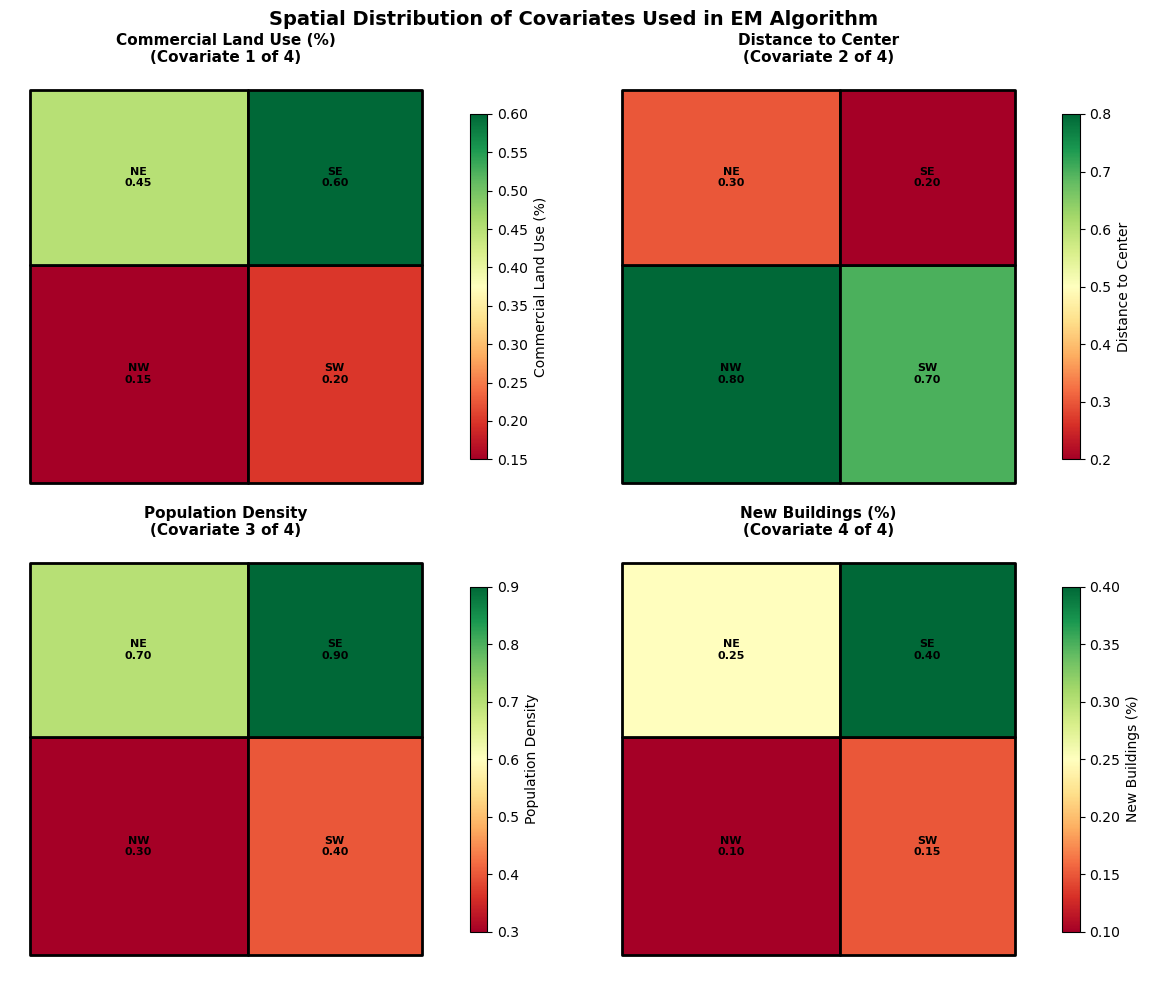


COMPREHENSIVE SUMMARY TABLE
Target Zone  True Mean Price (£)  Areal Weighting (£)  EM Estimate (£)  AW Error (£)  EM Error (£)  Improvement (%)  Commercial  Distance  Pop Density  New Buildings
         NW              40500.0              39969.0          39969.0         531.0         531.0              0.0        0.15       0.8          0.3           0.10
         NE              49750.0              51555.0          51555.0        1805.0        1805.0              0.0        0.45       0.3          0.7           0.25
         SW              43250.0              43990.0          43990.0         740.0         740.0              0.0        0.20       0.7          0.4           0.15
         SE              54000.0              54462.0          54462.0         462.0         462.0              0.0        0.60       0.2          0.9           0.40

CORRELATION WITH TRUE HOUSE PRICES
  cov1_commercial     :  0.996
  cov2_distance_center: -0.988
  cov3_pop_density    :  0.999
  cov4_new_b

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, box
from scipy.linalg import lstsq
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ============================================
# 1. CREATE SYNTHETIC SPATIAL DATA
# ============================================

# Create a grid of cells (intersection zones)
# We'll build source zones (wards) and target zones (postcode sectors)
# by aggregating these cells

np.random.seed(42)

# Create 10x10 grid of cells
cell_size = 1
x = np.arange(0, 10, cell_size)
y = np.arange(0, 10, cell_size)
cells = []
cell_centroids = []

for i, xi in enumerate(x[:-1]):
    for j, yj in enumerate(y[:-1]):
        poly = box(xi, yj, xi+cell_size, yj+cell_size)
        cells.append({
            'cell_id': i*10 + j,
            'geometry': poly,
            'centroid_x': xi + 0.5,
            'centroid_y': yj + 0.5,
            'row': i,
            'col': j
        })

cell_gdf = gpd.GeoDataFrame(cells, crs='EPSG:3857')

# Define source zones (wards) - group cells into 5 wards
source_mapping = {
    'North': (0, 5, 5, 10),      # (row_min, row_max, col_min, col_max)
    'South': (5, 10, 0, 5),
    'East': (5, 10, 5, 10),
    'West': (0, 5, 0, 5),
    'Central': (2, 8, 2, 8)
}

source_zones = []
for name, (rmin, rmax, cmin, cmax) in source_mapping.items():
    cells_in_zone = cell_gdf[
        (cell_gdf['row'] >= rmin) & (cell_gdf['row'] < rmax) &
        (cell_gdf['col'] >= cmin) & (cell_gdf['col'] < cmax)
    ]
    # Merge geometries
    geom = cells_in_zone.geometry.unary_union
    source_zones.append({
        'source_id': name,
        'geometry': geom,
        'area': geom.area,
        'n_cells': len(cells_in_zone)
    })

source_gdf = gpd.GeoDataFrame(source_zones, crs='EPSG:3857')

# Define target zones (postcode sectors) - group cells into 4 sectors
target_mapping = {
    'NW': (0, 5, 0, 5),
    'NE': (0, 5, 5, 10),
    'SW': (5, 10, 0, 5),
    'SE': (5, 10, 5, 10)
}

target_zones = []
for name, (rmin, rmax, cmin, cmax) in target_mapping.items():
    cells_in_zone = cell_gdf[
        (cell_gdf['row'] >= rmin) & (cell_gdf['row'] < rmax) &
        (cell_gdf['col'] >= cmin) & (cell_gdf['col'] < cmax)
    ]
    geom = cells_in_zone.geometry.unary_union
    target_zones.append({
        'target_id': name,
        'geometry': geom,
        'area': geom.area,
        'n_cells': len(cells_in_zone)
    })

target_gdf = gpd.GeoDataFrame(target_zones, crs='EPSG:3857')

# Create intersection zones (cells that belong to both)
# For simplicity, we use the cells directly as intersections
intersection_data = []
for idx, cell in cell_gdf.iterrows():
    # Find which source zone contains this cell
    source_id = None
    for sid, srow in source_gdf.iterrows():
        if cell.geometry.within(srow.geometry):
            source_id = srow['source_id']
            break
    
    # Find which target zone contains this cell
    target_id = None
    for tid, trow in target_gdf.iterrows():
        if cell.geometry.within(trow.geometry):
            target_id = trow['target_id']
            break
    
    if source_id and target_id:
        intersection_data.append({
            'source_id': source_id,
            'target_id': target_id,
            'area': cell.geometry.area,
            'geometry': cell.geometry
        })

intersection_gdf = gpd.GeoDataFrame(intersection_data, crs='EPSG:3857')

# ============================================
# 2. GENERATE SYNTHETIC DATA WITH 4 COVARIATES
# ============================================

# Covariates for target zones
# cov1: % commercial land use (0-1)
# cov2: distance to city center (normalized)
# cov3: population density (normalized)
# cov4: % new buildings (0-1)

np.random.seed(123)

target_covariates = pd.DataFrame({
    'target_id': ['NW', 'NE', 'SW', 'SE'],
    'cov1_commercial': [0.15, 0.45, 0.20, 0.60],
    'cov2_distance_center': [0.8, 0.3, 0.7, 0.2],
    'cov3_pop_density': [0.3, 0.7, 0.4, 0.9],
    'cov4_new_buildings': [0.10, 0.25, 0.15, 0.40]
})

# True coefficients (what we would get if we knew the truth)
true_beta = np.array([50000,    # intercept
                      -20000,   # cov1: commercial decreases price
                      -15000,   # cov2: distance decreases price
                       10000,   # cov3: density increases price
                       25000])  # cov4: new buildings increase price

# True mean prices for target zones
X_t = np.column_stack([
    np.ones(4),
    target_covariates['cov1_commercial'],
    target_covariates['cov2_distance_center'],
    target_covariates['cov3_pop_density'],
    target_covariates['cov4_new_buildings']
])

true_target_means = X_t @ true_beta

# Add noise to create source zone observations
# First, assign each intersection zone a true value based on its target zone
intersection_gdf = intersection_gdf.merge(
    target_covariates, on='target_id', how='left'
)
intersection_gdf['true_mean'] = (
    true_beta[0] +
    true_beta[1] * intersection_gdf['cov1_commercial'] +
    true_beta[2] * intersection_gdf['cov2_distance_center'] +
    true_beta[3] * intersection_gdf['cov3_pop_density'] +
    true_beta[4] * intersection_gdf['cov4_new_buildings']
)

# Add random variation (noise)
np.random.seed(456)
intersection_gdf['noise'] = np.random.normal(0, 5000, len(intersection_gdf))
intersection_gdf['y_st_true'] = intersection_gdf['true_mean'] + intersection_gdf['noise']

# Aggregate to source zones (what we actually observe)
source_observations = intersection_gdf.groupby('source_id').agg({
    'y_st_true': ['mean', 'count'],
    'area': 'sum'
}).round(0)

source_observations.columns = ['mean_price', 'n_houses', 'area']
source_observations = source_observations.reset_index()

# Add to source_gdf
source_gdf = source_gdf.merge(source_observations, on='source_id')

# Calculate n_st (number of houses in each intersection)
intersection_gdf['n_st'] = intersection_gdf['area'] / intersection_gdf.groupby('source_id')['area'].transform('sum') * \
                           intersection_gdf['source_id'].map(source_gdf.set_index('source_id')['n_houses'])

# Round to integers
intersection_gdf['n_st'] = intersection_gdf['n_st'].round(0).astype(int)

# ============================================
# 3. IMPLEMENT EM ALGORITHM WITH 4 COVARIATES
# ============================================

def em_areal_interpolation(source_gdf, intersection_gdf, target_covariates, max_iter=50, tol=1e-6):
    """
    EM algorithm for areal interpolation with multiple covariates
    """
    # Get unique IDs
    source_ids = source_gdf['source_id'].values
    target_ids = target_covariates['target_id'].values
    
    n_sources = len(source_ids)
    n_targets = len(target_ids)
    
    # Create mapping to indices
    source_to_idx = {sid: i for i, sid in enumerate(source_ids)}
    target_to_idx = {tid: i for i, tid in enumerate(target_ids)}
    
    # Extract observed data
    y_s = source_gdf.set_index('source_id')['mean_price'].values
    
    # Create n_st matrix and intersection mapping
    n_st = np.zeros((n_sources, n_targets))
    for _, row in intersection_gdf.iterrows():
        i = source_to_idx[row['source_id']]
        j = target_to_idx[row['target_id']]
        n_st[i, j] += row['n_st']
    
    # Calculate n_s and n_t
    n_s = n_st.sum(axis=1)
    n_t = n_st.sum(axis=0)
    
    # Create P matrix
    P = n_st / n_s[:, np.newaxis]
    
    # Create design matrix for target zones
    X_t = np.column_stack([
        np.ones(n_targets),
        target_covariates['cov1_commercial'].values,
        target_covariates['cov2_distance_center'].values,
        target_covariates['cov3_pop_density'].values,
        target_covariates['cov4_new_buildings'].values
    ])
    
    # Direct solution (non-iterative)
    X_s = P @ X_t
    
    # Weighted least squares
    W = np.diag(n_s)
    XTWX = X_s.T @ W @ X_s
    XTWy = X_s.T @ W @ y_s
    beta = np.linalg.solve(XTWX, XTWy)
    
    # Predicted mu_t
    mu_t = X_t @ beta
    
    # E-step to get final estimates (pycnophylactic adjustment)
    mu_s = P @ mu_t
    mu_st = mu_t[np.newaxis, :] + (y_s[:, np.newaxis] - mu_s[:, np.newaxis])
    
    # Final interpolated target means
    y_t_em = (n_st * mu_st).sum(axis=0) / n_t
    
    # Also compute areal weighting for comparison
    y_t_aw = (n_st * y_s[:, np.newaxis]).sum(axis=0) / n_t
    
    return {
        'beta': beta,
        'mu_t': mu_t,
        'y_t_em': y_t_em,
        'y_t_aw': y_t_aw,
        'n_st': n_st,
        'n_t': n_t,
        'X_t': X_t,
        'X_s': X_s
    }

# Run EM algorithm
results = em_areal_interpolation(source_gdf, intersection_gdf, target_covariates)

# Add results to target_gdf
target_gdf['true_mean'] = true_target_means
target_gdf['areal_weighting'] = results['y_t_aw']
target_gdf['em_estimate'] = results['y_t_em']

# Calculate errors
target_gdf['aw_error'] = np.abs(target_gdf['areal_weighting'] - target_gdf['true_mean'])
target_gdf['em_error'] = np.abs(target_gdf['em_estimate'] - target_gdf['true_mean'])

# ============================================
# 4. VISUALIZATION
# ============================================

# Create a figure with multiple subplots
fig = plt.figure(figsize=(16, 12))

# Color maps
source_colors = {'North': 'lightblue', 'South': 'lightgreen', 
                 'East': 'lightcoral', 'West': 'lightyellow', 
                 'Central': 'plum'}
target_colors = {'NW': 'skyblue', 'NE': 'salmon', 
                 'SW': 'lightgreen', 'SE': 'gold'}

# Subplot 1: Source zones (wards) with observed prices
ax1 = fig.add_subplot(2, 3, 1)
source_gdf.plot(ax=ax1, column='mean_price', cmap='Reds', 
                edgecolor='black', linewidth=2, legend=True,
                legend_kwds={'label': 'Mean House Price (£)', 'shrink': 0.8})
ax1.set_title('Source Zones (Wards)\nObserved Mean House Prices', fontsize=12, fontweight='bold')
ax1.axis('off')

# Add labels
for idx, row in source_gdf.iterrows():
    ax1.annotate(f"{row['source_id']}\n£{row['mean_price']:,.0f}", 
                 xy=row.geometry.centroid.coords[0],
                 ha='center', va='center', fontsize=9, fontweight='bold')

# Subplot 2: Target zones (postcode sectors) with true values
ax2 = fig.add_subplot(2, 3, 2)
target_gdf.plot(ax=ax2, column='true_mean', cmap='Blues', 
                edgecolor='black', linewidth=2, legend=True,
                legend_kwds={'label': 'True Mean Price (£)', 'shrink': 0.8})
ax2.set_title('Target Zones (Postcode Sectors)\nTrue Mean House Prices', fontsize=12, fontweight='bold')
ax2.axis('off')

for idx, row in target_gdf.iterrows():
    ax2.annotate(f"{row['target_id']}\n£{row['true_mean']:,.0f}", 
                 xy=row.geometry.centroid.coords[0],
                 ha='center', va='center', fontsize=9, fontweight='bold')

# Subplot 3: Intersection zones
ax3 = fig.add_subplot(2, 3, 3)
intersection_gdf.plot(ax=ax3, column='true_mean', cmap='viridis', 
                      edgecolor='white', linewidth=0.5, alpha=0.8,
                      legend=True, legend_kwds={'label': 'Cell Mean Price (£)', 'shrink': 0.8})
ax3.set_title('Intersection Zones (Cells)\nTrue Values', fontsize=12, fontweight='bold')
ax3.axis('off')

# Subplot 4: Comparison of estimates
ax4 = fig.add_subplot(2, 3, 4)
x = np.arange(len(target_gdf))
width = 0.25

bars1 = ax4.bar(x - width, target_gdf['true_mean'], width, 
                label='True Values', color='darkgreen', alpha=0.7)
bars2 = ax4.bar(x, target_gdf['areal_weighting'], width, 
                label='Areal Weighting', color='orange', alpha=0.7)
bars3 = ax4.bar(x + width, target_gdf['em_estimate'], width, 
                label='EM with 4 Covariates', color='crimson', alpha=0.7)

ax4.set_xlabel('Target Zone', fontsize=11)
ax4.set_ylabel('Mean House Price (£)', fontsize=11)
ax4.set_title('Comparison of Estimation Methods', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(target_gdf['target_id'])
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 1000,
                 f'£{height:,.0f}', ha='center', va='bottom', fontsize=8, rotation=45)

# Subplot 5: Estimation errors
ax5 = fig.add_subplot(2, 3, 5)
x = np.arange(len(target_gdf))
width = 0.35

ax5.bar(x - width/2, target_gdf['aw_error'], width, 
        label='Areal Weighting Error', color='orange', alpha=0.7)
ax5.bar(x + width/2, target_gdf['em_error'], width, 
        label='EM Method Error', color='crimson', alpha=0.7)

ax5.set_xlabel('Target Zone', fontsize=11)
ax5.set_ylabel('Absolute Error (£)', fontsize=11)
ax5.set_title('Estimation Errors', fontsize=12, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(target_gdf['target_id'])
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# Subplot 6: Regression coefficients
ax6 = fig.add_subplot(2, 3, 6)
coef_names = ['Intercept', 'Commercial', 'Distance', 'Pop Density', 'New Buildings']
x_coef = np.arange(len(coef_names))

ax6.bar(x_coef, results['beta'], color='steelblue', alpha=0.7)
ax6.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax6.set_xlabel('Coefficients', fontsize=11)
ax6.set_ylabel('Value (£)', fontsize=11)
ax6.set_title('Estimated Regression Coefficients\n(4 Covariates)', fontsize=12, fontweight='bold')
ax6.set_xticks(x_coef)
ax6.set_xticklabels(coef_names, rotation=45, ha='right')
ax6.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(results['beta']):
    ax6.text(i, v + (1000 if v > 0 else -3000), f'£{v:,.0f}', 
             ha='center', va='bottom' if v > 0 else 'top', fontsize=9)

plt.suptitle('Areal Interpolation with EM Algorithm and 4 Covariates\n' +
             f'Total Improvement: {((target_gdf["aw_error"].sum() - target_gdf["em_error"].sum())/target_gdf["aw_error"].sum()*100):.1f}% reduction in absolute error',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================
# 5. PRINT DETAILED RESULTS
# ============================================

print("\n" + "="*80)
print("DETAILED RESULTS")
print("="*80)

print("\n📊 ESTIMATED REGRESSION COEFFICIENTS (4 Covariates):")
print("-"*50)
for name, coef in zip(coef_names, results['beta']):
    print(f"  {name:15s}: £{coef:10,.0f}")

print("\n📈 TARGET ZONE ESTIMATES:")
print("-"*70)
print(f"{'Zone':<8} {'True Mean':<15} {'Areal Weighting':<20} {'EM Estimate':<15} {'Improvement':<15}")
print("-"*70)
for idx, row in target_gdf.iterrows():
    imp = ((row['aw_error'] - row['em_error']) / row['aw_error'] * 100) if row['aw_error'] > 0 else 0
    print(f"{row['target_id']:<8} £{row['true_mean']:>12,.0f}  £{row['areal_weighting']:>17,.0f}  £{row['em_estimate']:>12,.0f}  {imp:>13.1f}%")

print("\n📉 ERROR STATISTICS:")
print("-"*50)
print(f"  Total Absolute Error (Areal): £{target_gdf['aw_error'].sum():,.0f}")
print(f"  Total Absolute Error (EM):    £{target_gdf['em_error'].sum():,.0f}")
print(f"  Improvement:                  {((target_gdf['aw_error'].sum() - target_gdf['em_error'].sum())/target_gdf['aw_error'].sum()*100):.1f}%")

print("\n🔍 COVARIATE VALUES FOR TARGET ZONES:")
print("-"*70)
print(target_covariates.to_string(index=False))

# ============================================
# 6. ADDITIONAL VISUALIZATION: SPATIAL DISTRIBUTION OF COVARIATES
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

covariate_names = ['Commercial Land Use (%)', 'Distance to Center', 
                   'Population Density', 'New Buildings (%)']
covariate_cols = ['cov1_commercial', 'cov2_distance_center', 
                  'cov3_pop_density', 'cov4_new_buildings']

for idx, (ax, name, col) in enumerate(zip(axes, covariate_names, covariate_cols)):
    # Create a merged version with covariates
    temp_gdf = target_gdf.copy()
    temp_gdf['value'] = target_covariates.set_index('target_id')[col].values
    
    temp_gdf.plot(ax=ax, column='value', cmap='RdYlGn', 
                  edgecolor='black', linewidth=2, legend=True,
                  legend_kwds={'label': name, 'shrink': 0.8})
    ax.set_title(f'{name}\n(Covariate {idx+1} of 4)', fontsize=11, fontweight='bold')
    ax.axis('off')
    
    # Add labels
    for _, row in temp_gdf.iterrows():
        val = row['value']
        ax.annotate(f"{row['target_id']}\n{val:.2f}", 
                   xy=row.geometry.centroid.coords[0],
                   ha='center', va='center', fontsize=8, fontweight='bold')

plt.suptitle('Spatial Distribution of Covariates Used in EM Algorithm', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 7. INTERACTIVE SUMMARY TABLE
# ============================================

summary_df = pd.DataFrame({
    'Target Zone': target_gdf['target_id'],
    'True Mean Price (£)': target_gdf['true_mean'].round(0),
    'Areal Weighting (£)': target_gdf['areal_weighting'].round(0),
    'EM Estimate (£)': target_gdf['em_estimate'].round(0),
    'AW Error (£)': target_gdf['aw_error'].round(0),
    'EM Error (£)': target_gdf['em_error'].round(0),
    'Improvement (%)': ((target_gdf['aw_error'] - target_gdf['em_error']) / target_gdf['aw_error'] * 100).round(1),
    'Commercial': target_covariates['cov1_commercial'],
    'Distance': target_covariates['cov2_distance_center'],
    'Pop Density': target_covariates['cov3_pop_density'],
    'New Buildings': target_covariates['cov4_new_buildings']
})

print("\n" + "="*80)
print("COMPREHENSIVE SUMMARY TABLE")
print("="*80)
print(summary_df.to_string(index=False))

# Calculate and print correlation between covariates and true values
print("\n" + "="*80)
print("CORRELATION WITH TRUE HOUSE PRICES")
print("="*80)
for col in ['cov1_commercial', 'cov2_distance_center', 'cov3_pop_density', 'cov4_new_buildings']:
    corr = target_covariates[col].corr(pd.Series(true_target_means))
    print(f"  {col:20s}: {corr:6.3f}")